<a href="https://colab.research.google.com/github/SadeepM/brain-tumor-mri-classifier/blob/main/brain_tumor_mri_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [176]:
!pip install torchmetrics

In [177]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor

# Import numpy, matplotlib and pandas for visualization
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Import accuracy function for measure accuracy
from torchmetrics.classification import MulticlassAccuracy

# Import timeit to measure time
from timeit import default_timer as timer

#Import Kaggle for get dataset
import kagglehub

# Import tqdm for progress bar
#from tqdm.auto import tqdm

In [178]:
# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [179]:
import os

data_path = path
print(os.listdir(data_path))

['Training', 'Testing']


In [180]:
training_data_path=path+"/Training"
test_data_path=path+"/Testing"

In [181]:
train_dataset = datasets.ImageFolder(training_data_path)
test_dataset = datasets.ImageFolder(test_data_path)

print(f"Size of Training data set: {len(train_dataset)}")
print(f"Size of test data set: {len(test_dataset)}")
print(f"Classes of data set: {train_dataset.class_to_idx}")

Size of Training data set: 5600
Size of test data set: 1600
Classes of data set: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [182]:
from PIL import Image
import random

img_path, label = random.choice(train_dataset.samples)
img = Image.open(img_path)
label
print("Path:", img_path)
print("Size:", img.size)   # (width, height)
print("Mode:", img.mode)   # RGB or grayscale

Path: /kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_1113.jpg
Size: (512, 512)
Mode: L


In [183]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # MRI scans can be slightly tilted
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(training_data_path, transform=transform)
test_data=datasets.ImageFolder(test_data_path,transform=transform)

In [184]:
img_tensor, label = train_data[1000]

print(type(img_tensor))
print(img_tensor.shape,label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224]) 0


In [185]:
img_tensor, label = test_data[1000]

print(type(img_tensor))
print(img_tensor.shape,label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224]) 2


In [186]:
# Classes of the dataset
class_names=test_data.classes
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [187]:
# Size of the samples
len(train_data),len(test_data)

(5600, 1600)

In [188]:
def denormalize(tensor):
    # Reverse of: (img - mean) / std  =>  (img * std) + mean
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

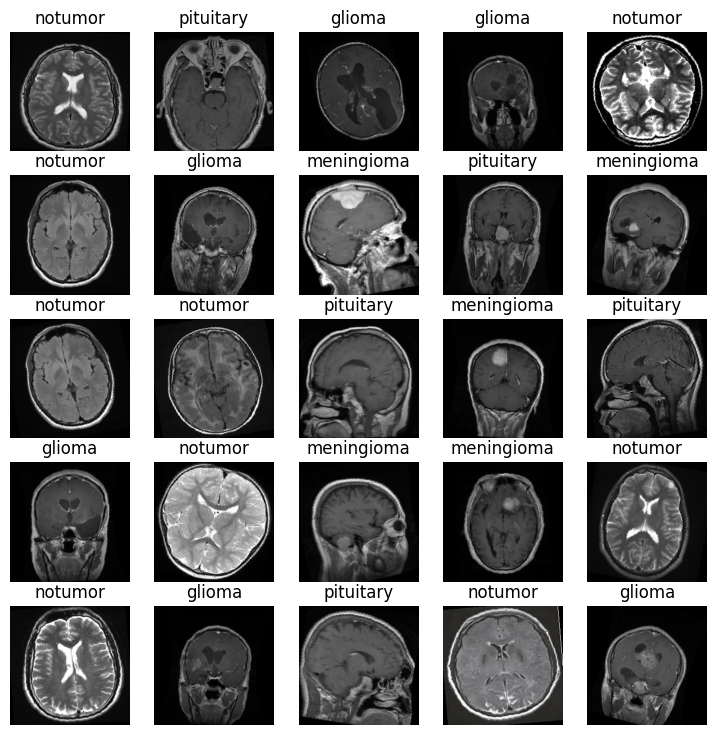

In [189]:
import torch
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=5,5
for i in range (1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(denormalize(img).permute(1, 2, 0).clamp(0, 1))
  plt.title(class_names[label])
  plt.axis(False)

In [190]:
# Create mini-batches of training data using PyTorch DataLoader
from torch.utils.data import DataLoader

# Setup the batch size
BATCH_SIZE=32

#Turn datasets into iterable (batches)
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True
                              )

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train dataloader: 175 batches of 32
Length of test dataloader: 50 batches of 32


In [191]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [192]:
#Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [193]:
#Create a Convolutional Neural Network
class CustomVGG(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,Output_shape:int):
    super().__init__()
    self.block_1=self.make_block(input_shape,hidden_units)
    self.block_2=self.make_block(hidden_units,hidden_units*2)
    self.block_3=self.make_block(hidden_units*2,hidden_units*2)


    self.classifier=nn.Sequential(
      nn.Flatten(),
      nn.Dropout(p=0.5),
      nn.LazyLinear(out_features=Output_shape)
    )

  def make_block(self,input_shape:int,Output_shape:int):
      return nn.Sequential(
          nn.Conv2d(in_channels=input_shape,out_channels=Output_shape,kernel_size=3,stride=1,padding=1),
          nn.BatchNorm2d(num_features=Output_shape),
          nn.ReLU(),
          nn.Conv2d(in_channels=Output_shape,out_channels=Output_shape,kernel_size=3,stride=1,padding=1),
          nn.BatchNorm2d(num_features=Output_shape),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,stride=2)
      )

  def forward(self,x:torch.Tensor):
    return self.classifier(self.block_2(self.block_1(x)))

In [194]:
torch.manual_seed(42)
model=CustomVGG(input_shape=3,
                 hidden_units=32,
                 Output_shape=len(class_names)).to(device)
model


CustomVGG(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(64,

In [195]:
# Setup optimizer and loss function
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [196]:
#Setup accuracy function
accuracy_fn=MulticlassAccuracy(num_classes=len(class_names)).to(device)

In [197]:
# Create functions for training and testing steps
def train_step(data_loader:torch.utils.data.DataLoader,
               model:torch.nn.Module,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn:torch.nn.Module,
               device:torch.device=device):
  train_loss,train_acc=0,0
  for batch,(X,y) in enumerate(data_loader):
    #send data to GPU
    X,y = X.to(device), y.to(device)

    # 1.Forward pass
    y_pred=model(X)

    # 2.Calculate loss
    loss=loss_fn(y_pred,y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_pred.argmax(dim=1),y)

    # 3.Optimizer zero grad
    optimizer.zero_grad()

    # 4.Back propagation
    loss.backward()

    # 5. Update parameters
    optimizer.step()

  #Calculate loss and accuracy per epoch and print out what's happening
  train_loss /= len(data_loader)
  train_accuracy =train_acc/len(data_loader)*100

  print(f"Train Loss: {train_loss:.5f}  | Train Accuracy: {train_accuracy:.2f}%")

def test_step(data_loader:torch.utils.data.DataLoader,
               model:torch.nn.Module,
               loss_fn:torch.nn.Module,
               accuracy_fn=torch.nn.Module,
               device:torch.device=device
               ):
  test_loss,test_acc=0,0
  model.eval() #Put model in eval mode

  #Turn on inference context manager
  with torch.inference_mode():
    for X,y in data_loader:

      #Send data to GPU
      X,y=X.to(device),y.to(device)

      # 1.Forward pass
      test_pred=model(X)

      # 2.Calculate loss and accuracy
      test_loss+=loss_fn(test_pred,y).item()
      test_acc +=accuracy_fn(test_pred.argmax(dim=1),y)

    # Calculate final test loss and accuracy and Print out the results
    test_loss /= len(data_loader)
    test_acc =test_acc/len(data_loader)*100
    print(f"Test Loss: {test_loss:.5f}  | Test Accuracy: {test_acc:.2f}%")

In [198]:
#Set the seed and start the timer
torch.manual_seed(42)
train_start=timer()

epochs=5
for epoch in range(epochs):
  print(f"Epoch: {epoch}\n----------------------------------------")
  train_step(data_loader=train_dataloader,
             model=model,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

  test_step(data_loader=test_dataloader,
            model=model,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)

  scheduler.step()

  current_lr = optimizer.param_groups[0]['lr']
  print(f"Learning Rate is now: {current_lr:.6f}")

  train_end=timer()

  total_time=train_end-train_start
  print(f"Train time: {total_time:.2f} seconds\n")

Epoch: 0
----------------------------------------
Train Loss: 0.95871  | Train Accuracy: 73.36%
Test Loss: 1.64008  | Test Accuracy: 67.04%
Learning Rate is now: 0.000100
Train time: 49.33 seconds

Epoch: 1
----------------------------------------
Train Loss: 0.41090  | Train Accuracy: 84.95%
Test Loss: 0.85664  | Test Accuracy: 81.27%
Learning Rate is now: 0.000100
Train time: 95.78 seconds

Epoch: 2
----------------------------------------
Train Loss: 0.31359  | Train Accuracy: 88.54%
Test Loss: 0.88061  | Test Accuracy: 84.59%
Learning Rate is now: 0.000010
Train time: 141.32 seconds

Epoch: 3
----------------------------------------
Train Loss: 0.21776  | Train Accuracy: 92.76%
Test Loss: 0.94916  | Test Accuracy: 84.49%
Learning Rate is now: 0.000010
Train time: 186.34 seconds

Epoch: 4
----------------------------------------
Train Loss: 0.20502  | Train Accuracy: 93.34%
Test Loss: 0.98398  | Test Accuracy: 85.68%
Learning Rate is now: 0.000010
Train time: 231.91 seconds



In [199]:
# Get trained model results
torch.manual_seed(42)

loss,acc=0,0

model.eval()
with torch.inference_mode():
  for X,y in test_dataloader:
    # Copy data into the target device
    X,y=X.to(device),y.to(device)
    #Make prediction with the trained model
    y_pred=model(X)

    #Accumulate the loss and accuracy values per batch
    loss+=loss_fn(y_pred,y)
    acc+=accuracy_fn(y_pred.argmax(dim=1),y)

  # Average loss and accuracy per batch
  loss/=len(test_dataloader)
  acc=acc/len(test_dataloader)*100

print(f"Loss: {loss:.5f}  | Accuracy: {acc:.2f}%")

Loss: 0.99831  | Accuracy: 85.06%


In [200]:
# Check Predictions
import random

random.seed(42)
test_sample=[]
test_label=[]
for sample,label in random.sample(list(test_data),k=25):
  test_sample.append(sample)
  test_label.append(label)

preds_ls=[]

model.eval()
with torch.inference_mode():
  for sample in test_sample:
    sample=torch.unsqueeze(sample,dim=0).to(device)
    #Forward pass
    pred_logit=model(sample)
    pred=torch.softmax(pred_logit.squeeze(),dim=0)

    #Get prediction
    preds_ls.append(pred.cpu())

  preds=torch.stack(preds_ls)

In [201]:
pred_classes=preds.argmax(dim=1)
pred_classes

tensor([3, 0, 0, 3, 0, 1, 3, 0, 3, 0, 3, 3, 2, 0, 3, 2, 0, 0, 0, 1, 2, 2, 3, 0,
        2])

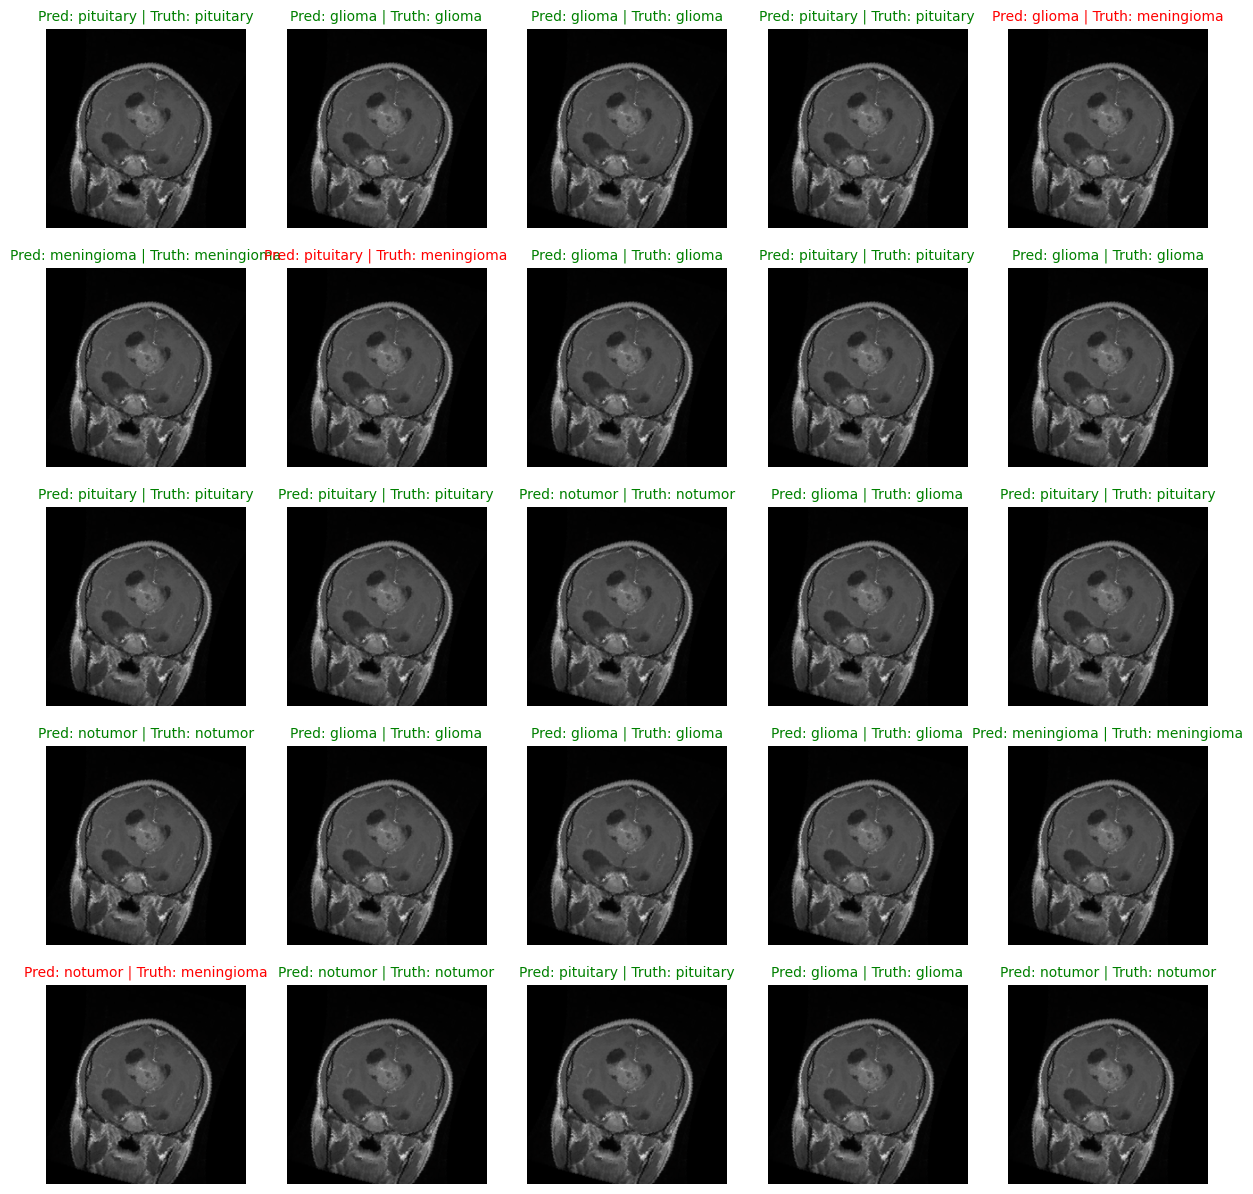

In [202]:
# Plot predictions
plt.figure(figsize=(15,15))
nrows,ncols=5,5
for i,sample in enumerate(test_sample):
  #Create subplot
  plt.subplot(nrows,ncols,i+1)

  #plot target image
  plt.imshow(denormalize(img).permute(1, 2, 0).clamp(0, 1))

  #Find the prediction label
  pred_label=class_names[pred_classes[i]]

  #Truth label
  truth_label=class_names[test_label[i]]

  # Create title text of the plot
  title_text=f"Pred: {pred_label} | Truth: {truth_label}"

  #Check for equality and change title color accordingly
  if pred_label==truth_label:
    plt.title(title_text,fontsize=10,c="g") # green text if correct
  else:
    plt.title(title_text,fontsize=10,c="r") #red text if wrong
  plt.axis(False)